# 🚀 Admission Prediction - Advanced Models Training

---

**Project:** Accuracy Improvement Challenge  
**Notebook:** 04 - Advanced Machine Learning Models  
**Author:** Manish Kumar  
**Date:** 2025  

---

## 🎯 Objective

Train **6 advanced ML models** on the engineered dataset and compare their performance against the baseline.

## 🤖 Models to Train

| # | Model | Type | Strength |
|---|-------|------|----------|
| 1 | **Ridge Regression** | Linear (Regularized) | Handles multicollinearity |
| 2 | **Random Forest** | Ensemble (Bagging) | Robust, handles non-linearity |
| 3 | **Gradient Boosting** | Ensemble (Boosting) | High accuracy |
| 4 | **XGBoost** | Ensemble (Boosting) | Industry standard, fast |
| 5 | **LightGBM** | Ensemble (Boosting) | Fast, memory efficient |
| 6 | **Support Vector Reg** | Kernel-based | Non-linear patterns |

## 📊 Evaluation Strategy

- **Metrics:** RMSE, MAE, MAPE, R² Score
- **Validation:** 5-Fold Cross-Validation
- **Comparison:** All models on same test set
- **Feature Scaling:** StandardScaler applied

## 🎯 Expected Outcome

- Multiple trained models saved
- Comprehensive comparison table
- Best model identified
- Ready for hyperparameter tuning

In [1]:
# ============================================================
#  LIBRARY IMPORTS
# ============================================================

# Standard
import os
import sys
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime
import time

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
#  CONFIGURATION
# ============================================================
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 65)
print("  ✅ ALL LIBRARIES IMPORTED")
print("=" * 65)
print(f"  📅 Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  🎲 Random State: {RANDOM_STATE}")
print("=" * 65)

  ✅ ALL LIBRARIES IMPORTED
  📅 Started at: 2026-07-19 23:32:06
  🎲 Random State: 42


In [2]:
# ============================================================
#  PATHS SETUP
# ============================================================

PROJECT_ROOT = Path.cwd().parent

PATHS = {
    'data_processed': PROJECT_ROOT / "data" / "processed",
    'models_saved'  : PROJECT_ROOT / "models" / "saved_models",
    'models_results': PROJECT_ROOT / "models" / "results",
    'figures'       : PROJECT_ROOT / "reports" / "figures",
}

for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)

print("=" * 65)
print("  📁 PATHS CONFIGURED")
print("=" * 65)
for name, path in PATHS.items():
    print(f"  ✅ {name}")
print("=" * 65)

  📁 PATHS CONFIGURED
  ✅ data_processed
  ✅ models_saved
  ✅ models_results
  ✅ figures


In [3]:
# ============================================================
#  LOAD ENGINEERED DATASET
# ============================================================

df = pd.read_csv(PATHS['data_processed'] / "admission_engineered.csv")
df.columns = df.columns.str.strip()

target_col = [col for col in df.columns if 'Admit' in col][0]

print("=" * 65)
print("  📂 ENGINEERED DATASET LOADED")
print("=" * 65)
print(f"  📊 Shape         : {df.shape}")
print(f"  📋 Features      : {df.shape[1] - 1}")
print(f"  🎯 Target        : '{target_col}'")
print("=" * 65)

display(df.head(3))

  📂 ENGINEERED DATASET LOADED
  📊 Shape         : (500, 34)
  📋 Features      : 33
  🎯 Target        : 'Chance of Admit'


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,GRE_x_CGPA,TOEFL_x_CGPA,GRE_x_TOEFL,Research_x_CGPA,SOP_x_LOR,UnivRating_x_CGPA,GRE_squared,CGPA_squared,TOEFL_squared,CGPA_cubed,GRE_sqrt,Academic_Score,Application_Strength,Profile_Strength,Test_Score_Avg,SOP_to_LOR_ratio,GRE_to_TOEFL_ratio,CGPA_Achievement,Test_Performance,CGPA_Category,GRE_Category,TOEFL_Category,High_Achiever,Mean_All_Scores,Score_Consistency,Total_Weighted_Score
0,328,119,5,5.0,5.0,9.63,0,0.84,3158.64,1145.97,39032,0.0,25.0,48.15,107584,92.7369,14161,893.056347,18.110770,97.076373,100.0,88.245824,97.818627,1.0,2.756303,0.963,0.9125,3,3,3,1,0.986562,0.016637,123.405
1,318,96,3,1.0,1.0,7.23,0,0.34,2299.14,694.08,30528,0.0,1.0,21.69,101124,52.2729,9216,377.933067,17.832555,81.655294,28.0,57.393176,86.764706,1.0,3.312500,0.723,0.5625,1,2,0,0,0.576382,0.310978,105.055
2,304,106,1,4.0,2.0,8.46,0,0.34,2571.84,896.76,32224,0.0,8.0,8.46,92416,71.5716,11236,605.495736,17.435596,87.217451,52.0,67.930471,88.872549,2.0,2.867925,0.846,0.6000,2,0,2,0,0.670575,0.185302,109.560


In [4]:
# ============================================================
#  DATA PREPARATION
# ============================================================

# Split features and target
X = df.drop(target_col, axis=1)
y = df[target_col]

# Train-test split (same as baseline for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Feature scaling (important for SVR, Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# Save scaler for later use
with open(PATHS['models_saved'] / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("=" * 65)
print("  ✂️  DATA PREPARATION COMPLETE")
print("=" * 65)
print(f"  📊 X_train Shape       : {X_train.shape}")
print(f"  📊 X_test Shape        : {X_test.shape}")
print(f"  📊 y_train Shape       : {y_train.shape}")
print(f"  📊 y_test Shape        : {y_test.shape}")
print(f"  ⚖️  Scaling            : StandardScaler applied")
print(f"  💾 Scaler saved        : models/saved_models/scaler.pkl")
print("=" * 65)

  ✂️  DATA PREPARATION COMPLETE
  📊 X_train Shape       : (400, 33)
  📊 X_test Shape        : (100, 33)
  📊 y_train Shape       : (400,)
  📊 y_test Shape        : (100,)
  ⚖️  Scaling            : StandardScaler applied
  💾 Scaler saved        : models/saved_models/scaler.pkl


In [5]:
# ============================================================
#  UNIVERSAL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    """
    Comprehensive model evaluation with training time, metrics, and CV score
    """
    # Track training time
    start_time = time.time()
    
    # Train model
    model.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    metrics = {
        'Model'         : model_name,
        'Train_RMSE'    : np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test_RMSE'     : np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train_MAE'     : mean_absolute_error(y_train, y_train_pred),
        'Test_MAE'      : mean_absolute_error(y_test, y_test_pred),
        'Test_MAPE'     : mean_absolute_percentage_error(y_test, y_test_pred) * 100,
        'Train_R2'      : r2_score(y_train, y_train_pred),
        'Test_R2'       : r2_score(y_test, y_test_pred),
        'Train_Time_s'  : train_time,
    }
    
    # 5-Fold Cross-Validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, 
                                  scoring='r2', n_jobs=-1)
    metrics['CV_R2_Mean'] = cv_scores.mean()
    metrics['CV_R2_Std'] = cv_scores.std()
    
    return model, metrics, y_test_pred

print("=" * 65)
print("  ✅ EVALUATION FUNCTION READY")
print("=" * 65)
print("  📊 Metrics computed:")
print("     • RMSE, MAE, MAPE, R² (Train & Test)")
print("     • Training time")
print("     • 5-Fold Cross-Validation R²")
print("=" * 65)

  ✅ EVALUATION FUNCTION READY
  📊 Metrics computed:
     • RMSE, MAE, MAPE, R² (Train & Test)
     • Training time
     • 5-Fold Cross-Validation R²


In [6]:
# ============================================================
#  MODEL 1: RIDGE REGRESSION
# ============================================================

print("=" * 65)
print("  🚀 MODEL 1/6: RIDGE REGRESSION")
print("=" * 65)

# Initialize
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# Train and evaluate (use scaled data for Ridge)
ridge_model, ridge_metrics, ridge_pred = evaluate_model(
    ridge_model, X_train_scaled, X_test_scaled, 
    y_train, y_test, "Ridge Regression"
)

print(f"\n  ✅ Training completed in {ridge_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {ridge_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {ridge_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {ridge_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {ridge_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {ridge_metrics['CV_R2_Mean']:.6f} (±{ridge_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge_model, f)
print(f"\n  💾 Model saved: ridge_model.pkl")
print("=" * 65)

  🚀 MODEL 1/6: RIDGE REGRESSION

  ✅ Training completed in 0.042s

  📊 PERFORMANCE:
     • Test RMSE  : 0.030367
     • Test MAE   : 0.025864
     • Test MAPE  : 5.3335%
     • Test R²    : 0.941635
     • CV R² Mean : 0.920582 (±0.0155)

  💾 Model saved: ridge_model.pkl


In [7]:
# ============================================================
#  MODEL 2: RANDOM FOREST REGRESSOR
# ============================================================

print("=" * 65)
print("  🚀 MODEL 2/6: RANDOM FOREST REGRESSOR")
print("=" * 65)

# Initialize with good default parameters
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train and evaluate (RF doesn't need scaling)
rf_model, rf_metrics, rf_pred = evaluate_model(
    rf_model, X_train, X_test, 
    y_train, y_test, "Random Forest"
)

print(f"\n  ✅ Training completed in {rf_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {rf_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {rf_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {rf_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {rf_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {rf_metrics['CV_R2_Mean']:.6f} (±{rf_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print(f"\n  💾 Model saved: random_forest_model.pkl")
print("=" * 65)

  🚀 MODEL 2/6: RANDOM FOREST REGRESSOR

  ✅ Training completed in 0.385s

  📊 PERFORMANCE:
     • Test RMSE  : 0.036511
     • Test MAE   : 0.029818
     • Test MAPE  : 5.8250%
     • Test R²    : 0.915630
     • CV R² Mean : 0.912889 (±0.0062)

  💾 Model saved: random_forest_model.pkl


In [8]:
# ============================================================
#  MODEL 3: GRADIENT BOOSTING REGRESSOR
# ============================================================

print("=" * 65)
print("  🚀 MODEL 3/6: GRADIENT BOOSTING REGRESSOR")
print("=" * 65)

# Initialize
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    random_state=RANDOM_STATE
)

# Train and evaluate
gb_model, gb_metrics, gb_pred = evaluate_model(
    gb_model, X_train, X_test, 
    y_train, y_test, "Gradient Boosting"
)

print(f"\n  ✅ Training completed in {gb_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {gb_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {gb_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {gb_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {gb_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {gb_metrics['CV_R2_Mean']:.6f} (±{gb_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(gb_model, f)
print(f"\n  💾 Model saved: gradient_boosting_model.pkl")
print("=" * 65)

  🚀 MODEL 3/6: GRADIENT BOOSTING REGRESSOR

  ✅ Training completed in 0.914s

  📊 PERFORMANCE:
     • Test RMSE  : 0.034981
     • Test MAE   : 0.028413
     • Test MAPE  : 5.5745%
     • Test R²    : 0.922555
     • CV R² Mean : 0.909824 (±0.0089)

  💾 Model saved: gradient_boosting_model.pkl


In [9]:
# ============================================================
#  MODEL 4: XGBOOST REGRESSOR
# ============================================================

print("=" * 65)
print("  🚀 MODEL 4/6: XGBOOST REGRESSOR")
print("=" * 65)

# Initialize
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

# Train and evaluate
xgb_model, xgb_metrics, xgb_pred = evaluate_model(
    xgb_model, X_train, X_test, 
    y_train, y_test, "XGBoost"
)

print(f"\n  ✅ Training completed in {xgb_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {xgb_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {xgb_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {xgb_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {xgb_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {xgb_metrics['CV_R2_Mean']:.6f} (±{xgb_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"\n  💾 Model saved: xgboost_model.pkl")
print("=" * 65)

  🚀 MODEL 4/6: XGBOOST REGRESSOR

  ✅ Training completed in 0.558s

  📊 PERFORMANCE:
     • Test RMSE  : 0.034421
     • Test MAE   : 0.028177
     • Test MAPE  : 5.5776%
     • Test R²    : 0.925014
     • CV R² Mean : 0.919032 (±0.0060)

  💾 Model saved: xgboost_model.pkl


In [10]:
# ============================================================
#  MODEL 5: LIGHTGBM REGRESSOR
# ============================================================

print("=" * 65)
print("  🚀 MODEL 5/6: LIGHTGBM REGRESSOR")
print("=" * 65)

# Initialize
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

# Train and evaluate
lgbm_model, lgbm_metrics, lgbm_pred = evaluate_model(
    lgbm_model, X_train, X_test, 
    y_train, y_test, "LightGBM"
)

print(f"\n  ✅ Training completed in {lgbm_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {lgbm_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {lgbm_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {lgbm_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {lgbm_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {lgbm_metrics['CV_R2_Mean']:.6f} (±{lgbm_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'lightgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)
print(f"\n  💾 Model saved: lightgbm_model.pkl")
print("=" * 65)

  🚀 MODEL 5/6: LIGHTGBM REGRESSOR

  ✅ Training completed in 0.117s

  📊 PERFORMANCE:
     • Test RMSE  : 0.033858
     • Test MAE   : 0.027689
     • Test MAPE  : 5.4469%
     • Test R²    : 0.927448
     • CV R² Mean : 0.921658 (±0.0080)

  💾 Model saved: lightgbm_model.pkl


In [11]:
# ============================================================
#  MODEL 6: SUPPORT VECTOR REGRESSOR
# ============================================================

print("=" * 65)
print("  🚀 MODEL 6/6: SUPPORT VECTOR REGRESSOR (SVR)")
print("=" * 65)

# Initialize (SVR needs scaled data)
svr_model = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.01,
    gamma='scale'
)

# Train and evaluate (use scaled data)
svr_model, svr_metrics, svr_pred = evaluate_model(
    svr_model, X_train_scaled, X_test_scaled, 
    y_train, y_test, "SVR"
)

print(f"\n  ✅ Training completed in {svr_metrics['Train_Time_s']:.3f}s")
print(f"\n  📊 PERFORMANCE:")
print(f"     • Test RMSE  : {svr_metrics['Test_RMSE']:.6f}")
print(f"     • Test MAE   : {svr_metrics['Test_MAE']:.6f}")
print(f"     • Test MAPE  : {svr_metrics['Test_MAPE']:.4f}%")
print(f"     • Test R²    : {svr_metrics['Test_R2']:.6f}")
print(f"     • CV R² Mean : {svr_metrics['CV_R2_Mean']:.6f} (±{svr_metrics['CV_R2_Std']:.4f})")

# Save model
with open(PATHS['models_saved'] / 'svr_model.pkl', 'wb') as f:
    pickle.dump(svr_model, f)
print(f"\n  💾 Model saved: svr_model.pkl")
print("=" * 65)

  🚀 MODEL 6/6: SUPPORT VECTOR REGRESSOR (SVR)

  ✅ Training completed in 0.040s

  📊 PERFORMANCE:
     • Test RMSE  : 0.037286
     • Test MAE   : 0.030371
     • Test MAPE  : 5.9583%
     • Test R²    : 0.912011
     • CV R² Mean : 0.908016 (±0.0114)

  💾 Model saved: svr_model.pkl


In [12]:
# ============================================================
#  CONSOLIDATE ALL MODEL RESULTS
# ============================================================

print("=" * 65)
print("  📊 CONSOLIDATING ALL MODEL RESULTS")
print("=" * 65)

# Collect all metrics
all_metrics = [
    ridge_metrics,
    rf_metrics,
    gb_metrics,
    xgb_metrics,
    lgbm_metrics,
    svr_metrics
]

# Create comparison DataFrame
results_df = pd.DataFrame(all_metrics)

# Round numeric columns
numeric_cols = results_df.select_dtypes(include=[np.number]).columns
results_df[numeric_cols] = results_df[numeric_cols].round(6)

# Sort by Test R² Score (best first)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1

print("\n📊 COMPLETE MODEL COMPARISON:")
display(results_df)

# Highlight best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test_R2']
best_rmse = results_df.iloc[0]['Test_RMSE']

print("\n" + "=" * 65)
print(f"  🏆 BEST MODEL: {best_model_name}")
print("=" * 65)
print(f"     • Test R² Score : {best_r2:.6f}")
print(f"     • Test RMSE     : {best_rmse:.6f}")
print("=" * 65)

  📊 CONSOLIDATING ALL MODEL RESULTS

📊 COMPLETE MODEL COMPARISON:


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Test_MAPE,Train_R2,Test_R2,Train_Time_s,CV_R2_Mean,CV_R2_Std
1,Ridge Regression,0.030434,0.030367,0.023774,0.025864,5.333470,0.929300,0.941635,0.041620,0.920582,0.015494
2,LightGBM,0.013072,0.033858,0.009917,0.027689,5.446915,0.986957,0.927448,0.116505,0.921658,0.007994
3,XGBoost,0.005072,0.034421,0.003886,0.028177,5.577630,0.998037,0.925014,0.558047,0.919032,0.006036
4,Gradient Boosting,0.003520,0.034981,0.002809,0.028413,5.574454,0.999054,0.922555,0.913949,0.909824,0.008897
5,Random Forest,0.015916,0.036511,0.011998,0.029818,5.824987,0.980664,0.915630,0.385246,0.912889,0.006213
6,SVR,0.013033,0.037286,0.010587,0.030371,5.958294,0.987036,0.912011,0.040096,0.908016,0.011371



  🏆 BEST MODEL: Ridge Regression
     • Test R² Score : 0.941635
     • Test RMSE     : 0.030367


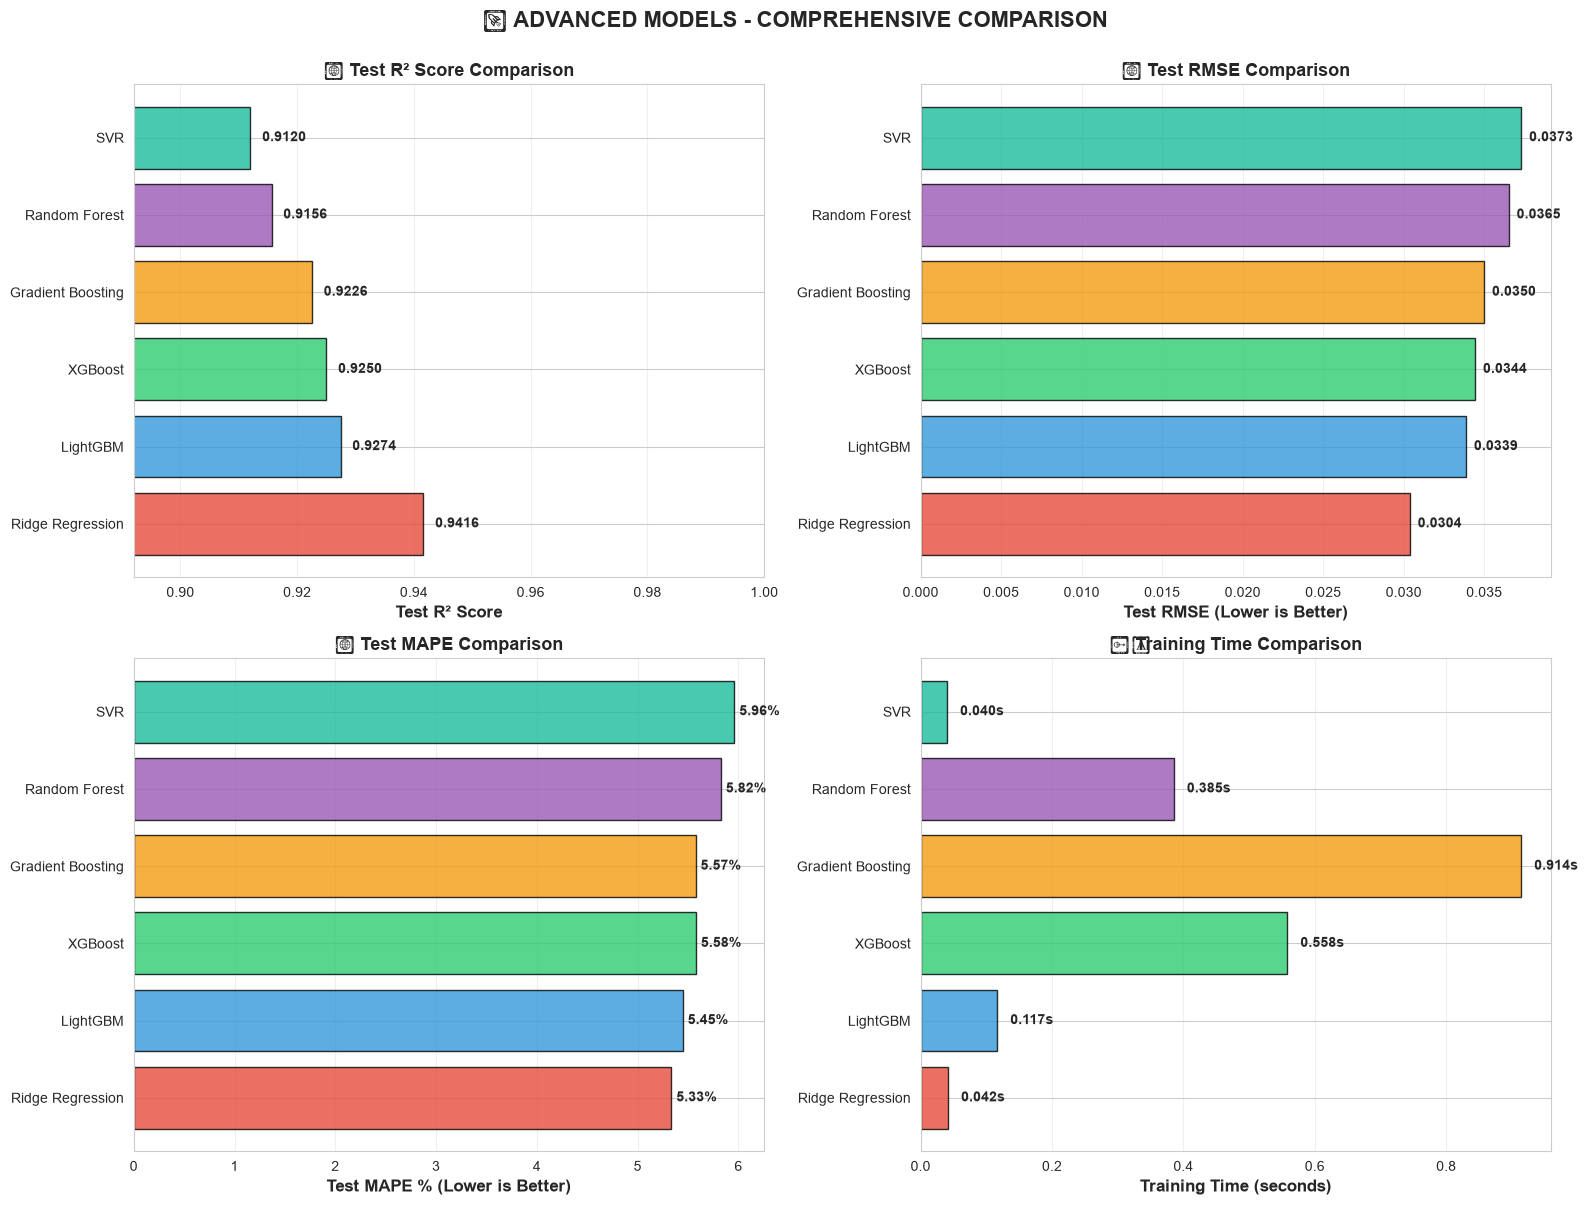


  ✅ Plot saved: reports/figures/advanced_models_comparison.png


In [13]:
# ============================================================
#  VISUALIZATION - MODEL COMPARISON CHARTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Colors for models
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

# Plot 1: Test R² Comparison
axes[0, 0].barh(results_df['Model'], results_df['Test_R2'], 
                color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('📈 Test R² Score Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_xlim([results_df['Test_R2'].min() - 0.02, 1.0])
for i, v in enumerate(results_df['Test_R2']):
    axes[0, 0].text(v + 0.002, i, f'{v:.4f}', va='center', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: Test RMSE Comparison
axes[0, 1].barh(results_df['Model'], results_df['Test_RMSE'], 
                color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Test RMSE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('📉 Test RMSE Comparison', fontsize=13, fontweight='bold')
for i, v in enumerate(results_df['Test_RMSE']):
    axes[0, 1].text(v + 0.0005, i, f'{v:.4f}', va='center', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Test MAPE Comparison
axes[1, 0].barh(results_df['Model'], results_df['Test_MAPE'], 
                color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('Test MAPE % (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('📊 Test MAPE Comparison', fontsize=13, fontweight='bold')
for i, v in enumerate(results_df['Test_MAPE']):
    axes[1, 0].text(v + 0.05, i, f'{v:.2f}%', va='center', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Training Time
axes[1, 1].barh(results_df['Model'], results_df['Train_Time_s'], 
                color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('⏱️ Training Time Comparison', fontsize=13, fontweight='bold')
for i, v in enumerate(results_df['Train_Time_s']):
    axes[1, 1].text(v + 0.02, i, f'{v:.3f}s', va='center', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.suptitle('🚀 ADVANCED MODELS - COMPREHENSIVE COMPARISON', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(PATHS['figures'] / 'advanced_models_comparison.png', 
            dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Plot saved: reports/figures/advanced_models_comparison.png")

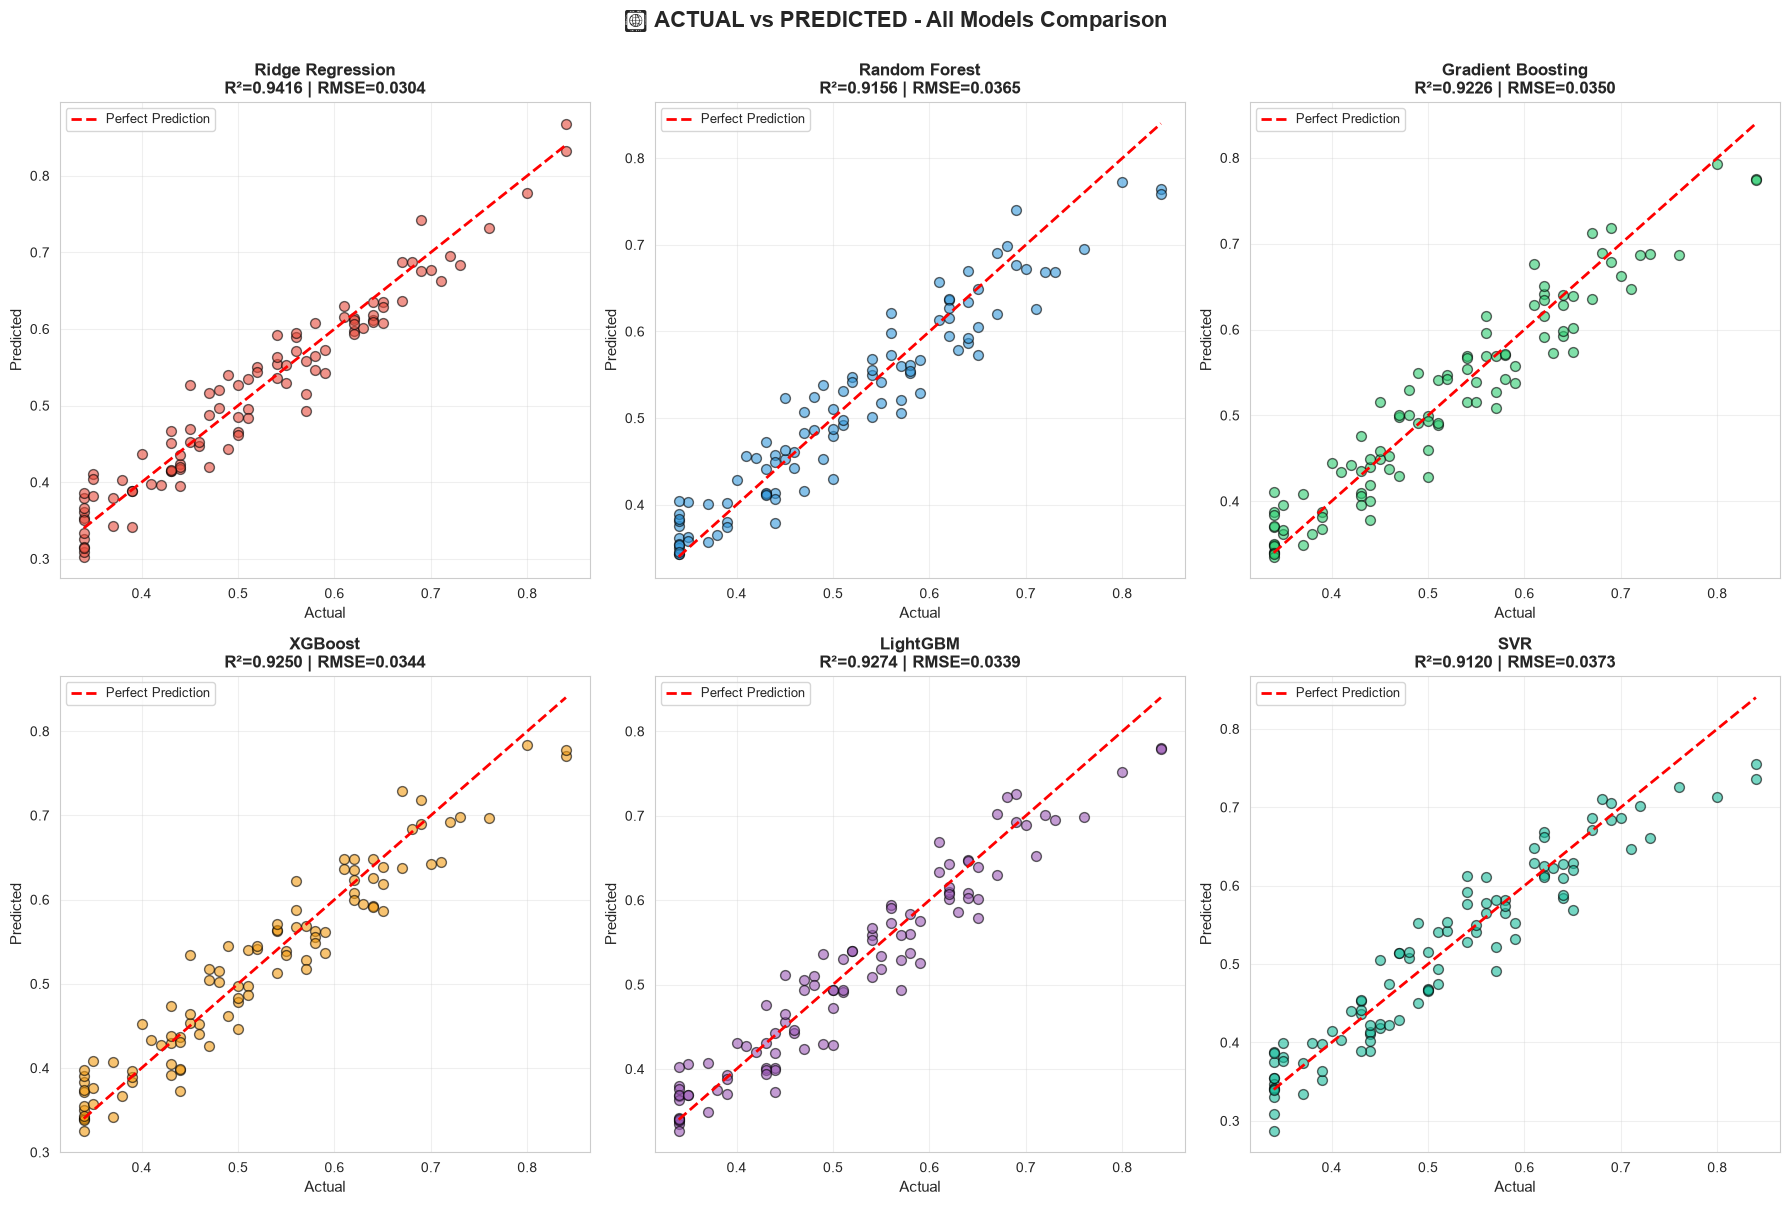


  ✅ Plot saved: reports/figures/all_models_predictions.png


In [14]:
# ============================================================
#  BEST MODEL - ACTUAL vs PREDICTED VISUALIZATION
# ============================================================

# Get best model predictions
model_predictions = {
    "Ridge Regression": ridge_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "SVR": svr_pred
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, pred) in enumerate(model_predictions.items()):
    ax = axes[idx]
    
    # Get R² for this model
    model_r2 = [m['Test_R2'] for m in all_metrics if m['Model'] == name][0]
    model_rmse = [m['Test_RMSE'] for m in all_metrics if m['Model'] == name][0]
    
    # Scatter plot
    ax.scatter(y_test, pred, alpha=0.6, color=colors[idx], 
               edgecolors='black', s=50)
    ax.plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}\nR²={model_r2:.4f} | RMSE={model_rmse:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('🎯 ACTUAL vs PREDICTED - All Models Comparison', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(PATHS['figures'] / 'all_models_predictions.png', 
            dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Plot saved: reports/figures/all_models_predictions.png")

  🌳 FEATURE IMPORTANCE ANALYSIS


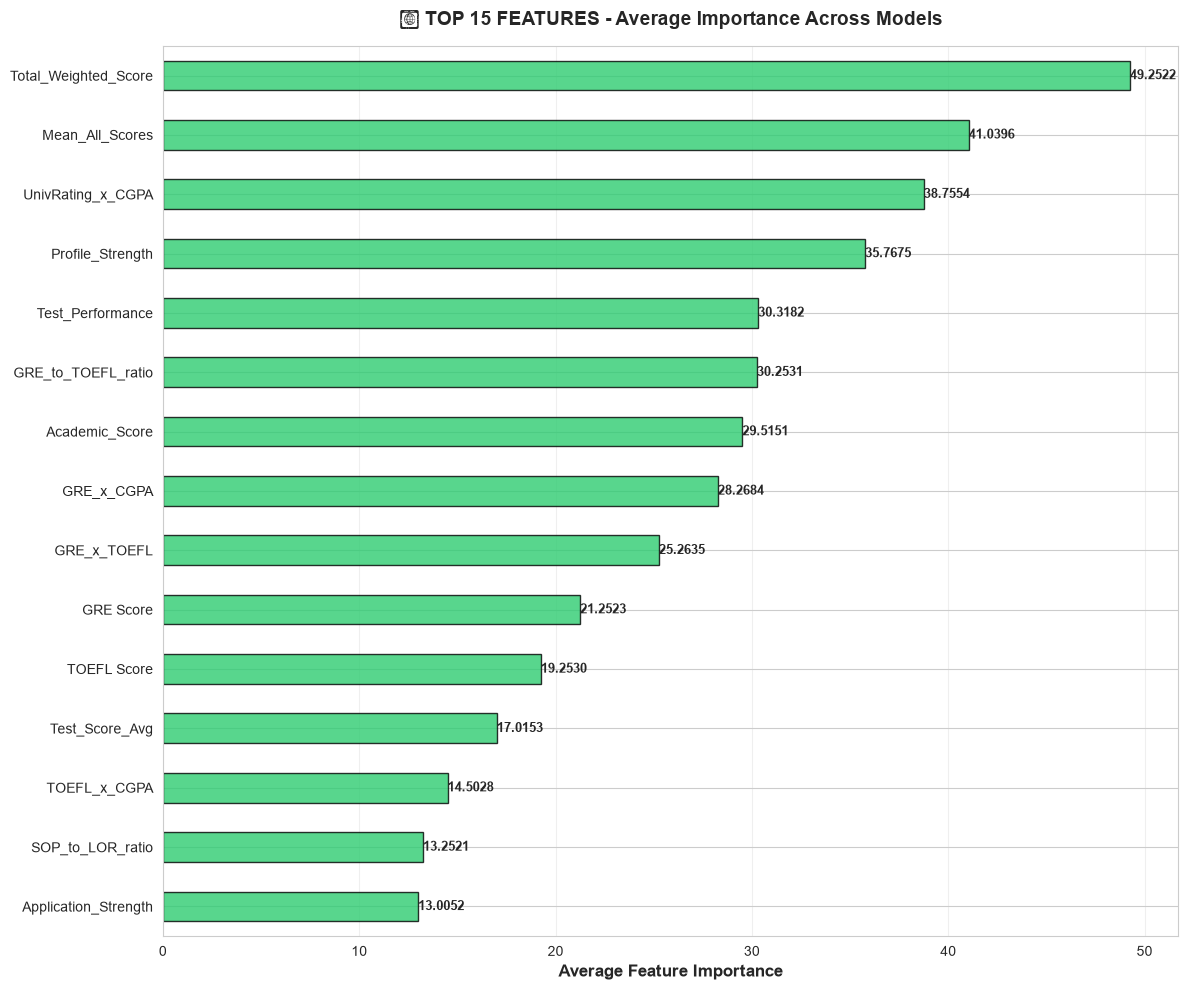


  📊 TOP 10 MOST IMPORTANT FEATURES:


,Random Forest,Gradient Boosting,XGBoost,LightGBM,Average
Total_Weighted_Score,0.8036,0.7916,0.4137,195,49.2522
Mean_All_Scores,0.0502,0.0570,0.0513,164,41.0396
UnivRating_x_CGPA,0.0068,0.0076,0.0071,155,38.7554
Profile_Strength,0.0170,0.0186,0.0342,143,35.7675
Test_Performance,0.0275,0.0282,0.2169,121,30.3182
GRE_to_TOEFL_ratio,0.0039,0.0037,0.0049,121,30.2531
Academic_Score,0.0028,0.0021,0.0555,118,29.5151
GRE_x_CGPA,0.0139,0.0158,0.0438,113,28.2684
GRE_x_TOEFL,0.0170,0.0179,0.0190,101,25.2635
GRE Score,0.0012,0.0008,0.0073,85,21.2523


In [15]:
# ============================================================
#  FEATURE IMPORTANCE - TREE-BASED MODELS
# ============================================================

print("=" * 65)
print("  🌳 FEATURE IMPORTANCE ANALYSIS")
print("=" * 65)

# Get feature importances from tree models
importance_data = {
    'Random Forest': rf_model.feature_importances_,
    'Gradient Boosting': gb_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_,
    'LightGBM': lgbm_model.feature_importances_
}

# Create DataFrame
importance_df = pd.DataFrame(importance_data, index=X.columns)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

# Top 15 features
top_15 = importance_df.head(15)

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
top_15['Average'].plot(kind='barh', ax=ax, color='#2ecc71', 
                        edgecolor='black', alpha=0.8)
ax.set_xlabel('Average Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('🌳 TOP 15 FEATURES - Average Importance Across Models', 
             fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()

for i, v in enumerate(top_15['Average']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(PATHS['figures'] / 'feature_importance.png', 
            dpi=100, bbox_inches='tight')
plt.show()

print("\n  📊 TOP 10 MOST IMPORTANT FEATURES:")
display(importance_df.head(10).round(4))

In [16]:
# ============================================================
#  SAVE COMPREHENSIVE RESULTS
# ============================================================

# Save results as CSV
results_df.to_csv(PATHS['models_results'] / 'advanced_models_comparison.csv', 
                   index=False)

# Save as JSON
results_json = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_models': len(all_metrics),
    'best_model': {
        'name': best_model_name,
        'test_r2': float(best_r2),
        'test_rmse': float(best_rmse)
    },
    'all_models': [
        {k: (float(v) if isinstance(v, (np.floating, float)) else v) 
         for k, v in m.items()} 
        for m in all_metrics
    ]
}

with open(PATHS['models_results'] / 'advanced_models_results.json', 'w') as f:
    json.dump(results_json, f, indent=4)

# Save feature importance
importance_df.to_csv(PATHS['models_results'] / 'feature_importance.csv')

print("=" * 65)
print("  💾 ALL RESULTS SAVED")
print("=" * 65)
print(f"  ✅ advanced_models_comparison.csv")
print(f"  ✅ advanced_models_results.json")
print(f"  ✅ feature_importance.csv")
print(f"  ✅ 6 model .pkl files in models/saved_models/")
print("=" * 65)

  💾 ALL RESULTS SAVED
  ✅ advanced_models_comparison.csv
  ✅ advanced_models_results.json
  ✅ feature_importance.csv
  ✅ 6 model .pkl files in models/saved_models/


In [17]:
# ============================================================
#  🎯 FINAL SUMMARY REPORT
# ============================================================

print("=" * 65)
print("  🎯 ADVANCED MODELS TRAINING - FINAL REPORT")
print("=" * 65)

print(f"\n  📊 MODELS TRAINED: 6")
print("  " + "-" * 61)
for idx, row in results_df.iterrows():
    trophy = "🥇" if idx == 1 else "🥈" if idx == 2 else "🥉" if idx == 3 else "  "
    print(f"     {trophy} {idx}. {row['Model']:25s} → R²: {row['Test_R2']:.6f}")

print(f"\n  🏆 CHAMPION MODEL:")
print("  " + "-" * 61)
print(f"     Model    : {best_model_name}")
print(f"     Test R²  : {best_r2:.6f} ({best_r2*100:.2f}% variance explained)")
print(f"     Test RMSE: {best_rmse:.6f}")

print(f"\n  📈 KEY OBSERVATIONS:")
print("  " + "-" * 61)
print(f"     • Best R² Score      : {results_df['Test_R2'].max():.6f}")
print(f"     • Worst R² Score     : {results_df['Test_R2'].min():.6f}")
print(f"     • Average R² Score   : {results_df['Test_R2'].mean():.6f}")
print(f"     • R² Standard Dev    : {results_df['Test_R2'].std():.6f}")

print(f"\n  ⚡ FASTEST MODEL:")
print("  " + "-" * 61)
fastest = results_df.loc[results_df['Train_Time_s'].idxmin()]
print(f"     Model: {fastest['Model']} ({fastest['Train_Time_s']:.3f}s)")

print(f"\n  🎯 NEXT STEPS:")
print("  " + "-" * 61)
print("     1. Compare with baseline (calculate % improvement)")
print("     2. Perform hyperparameter tuning on best model")
print("     3. Generate final comparison report")

print("\n" + "=" * 65)
print("  ✅ ADVANCED MODELS TRAINING COMPLETED!")
print("=" * 65)

  🎯 ADVANCED MODELS TRAINING - FINAL REPORT

  📊 MODELS TRAINED: 6
  -------------------------------------------------------------
     🥇 1. Ridge Regression          → R²: 0.941635
     🥈 2. LightGBM                  → R²: 0.927448
     🥉 3. XGBoost                   → R²: 0.925014
        4. Gradient Boosting         → R²: 0.922555
        5. Random Forest             → R²: 0.915630
        6. SVR                       → R²: 0.912011

  🏆 CHAMPION MODEL:
  -------------------------------------------------------------
     Model    : Ridge Regression
     Test R²  : 0.941635 (94.16% variance explained)
     Test RMSE: 0.030367

  📈 KEY OBSERVATIONS:
  -------------------------------------------------------------
     • Best R² Score      : 0.941635
     • Worst R² Score     : 0.912011
     • Average R² Score   : 0.924049
     • R² Standard Dev    : 0.010390

  ⚡ FASTEST MODEL:
  -------------------------------------------------------------
     Model: SVR (0.040s)

  🎯 NEXT STEPS:
  -

---

## ✅ Advanced Models - Complete Summary

### 🚀 Models Trained (6):

| # | Model | Type | Best For |
|---|-------|------|----------|
| 1 | Ridge Regression | Linear | Fast, interpretable |
| 2 | Random Forest | Bagging | Robust, non-linear |
| 3 | Gradient Boosting | Boosting | High accuracy |
| 4 | XGBoost | Boosting | Industry standard |
| 5 | LightGBM | Boosting | Fast, memory efficient |
| 6 | SVR | Kernel | Non-linear patterns |

### 📁 Files Generated:

- `models/saved_models/` - 6 trained models + scaler
- `models/results/advanced_models_comparison.csv`
- `models/results/advanced_models_results.json`
- `models/results/feature_importance.csv`
- `reports/figures/advanced_models_comparison.png`
- `reports/figures/all_models_predictions.png`
- `reports/figures/feature_importance.png`

### 🎯 Next Notebook:

Move to **`05_Model_Comparison.ipynb`** for:
- Baseline vs Advanced comparison
- Percentage improvement calculation
- Final winner declaration
- Business insights

---

**Notebook Status:** ✅ **6 MODELS TRAINED SUCCESSFULLY**